In [1]:
import os

os.chdir("..")
os.getcwd()

'/home/borealis/Documents/work/projects/work_tests/SpeakVer'

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T

from src.data.audio_preprocessor import AudioPreprocessor
from src.model.embedding_extractor import EmbeddingExtractor
from src.train.speaker_dataset import SpeakerDataset


In [3]:
MAX_BATCH_SIZE = 64
MIN_BATCH_SIZE = 4
TARGET_SR = 8000

# Paths
TRAIN_PATH = "speaker_dataset_new/train"
VAL_PATH = "speaker_dataset_new/val"
TEST_PATH = "speaker_dataset_new/test"
LENGTHS_CACHE_PATH = "speaker_dataset_new/lengths_cache.pkl"

MIC_TYPE = "throat_microphone"

In [4]:
train_preprocessor = AudioPreprocessor(
    resample=True,
    augment=True,
    fix_length=False,
    target_sr=TARGET_SR,
    vad_search_time=0.05,
    vad_trigger_level=12,
    target_peak=0.9
)
val_preprocessor = AudioPreprocessor(
    resample=True,
    augment=False,
    fix_length=False,
    target_sr=TARGET_SR,
    vad_search_time=0.05,
    vad_trigger_level=12,
    target_peak=0.9
)
test_preprocessor = AudioPreprocessor(
    resample=True,
    augment=False,
    fix_length=False,
    target_sr=TARGET_SR,
    vad_search_time=0.05,
    vad_trigger_level=12,
    target_peak=0.9
)

In [5]:
train_dataset = SpeakerDataset(
    TRAIN_PATH,
    preprocessor=train_preprocessor,
    return_audio=True,
    microphone=MIC_TYPE,
)
val_dataset = SpeakerDataset(
    VAL_PATH,
    preprocessor=val_preprocessor,
    return_audio=False,
    microphone=MIC_TYPE,
)
test_dataset = SpeakerDataset(
    TEST_PATH,
    preprocessor=test_preprocessor,
    return_audio=False,
    microphone=MIC_TYPE,
)

In [6]:
train_dataset_stats = train_dataset.statistics()
val_dataset_stats = val_dataset.statistics()
test_dataset_stats = test_dataset.statistics()

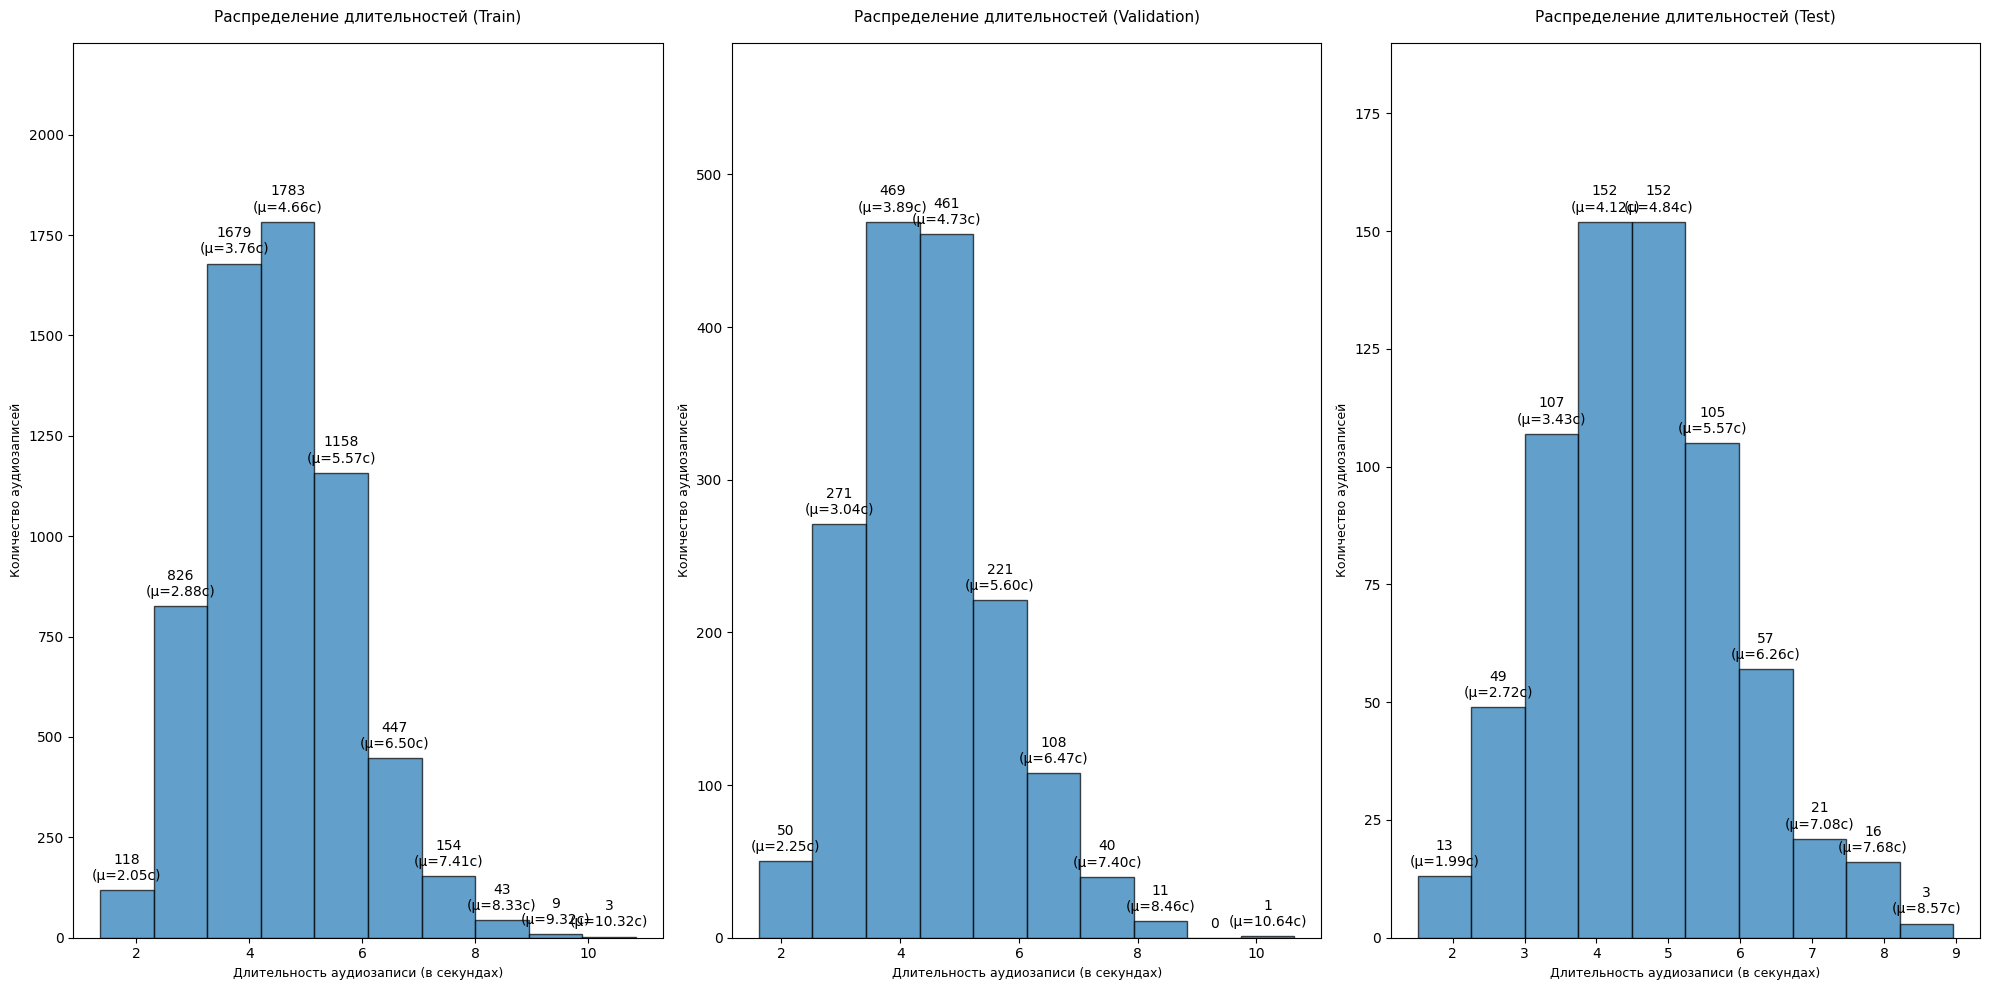

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

datasets = {
    "Train": train_dataset_stats["durations_distribution"],
    "Validation": val_dataset_stats["durations_distribution"],
    "Test": test_dataset_stats["durations_distribution"]
}


def draw_duration_hist(ax, data, dataset_name):
    data_arr = np.array(data)
    
    n, bins, patches = ax.hist(data_arr, edgecolor="black", alpha=0.7)
    
    for i in range(len(patches)):
        if i == len(patches) - 1:
            mask = (data_arr >= bins[i]) & (data_arr <= bins[i + 1])
        else:
            mask = (data_arr >= bins[i]) & (data_arr < bins[i + 1])
            
        bin_data = data_arr[mask]
        count = int(n[i])
        
        if count > 0:
            bin_mean = bin_data.mean()
            label_text = f"{count}\n(μ={bin_mean:.2f}с)"
        else:
            label_text = "0"
            
        x_pos = patches[i].get_x() + patches[i].get_width() / 2
        y_pos = patches[i].get_height()
        
        ax.text(
            x_pos, y_pos + (max(n) * 0.01), 
            label_text, 
            ha='center', va='bottom', 
            fontsize=10
        )
        
    ax.set_title(f"Распределение длительностей ({dataset_name})", fontsize=11, pad=15)
    ax.set_xlabel("Длительность аудиозаписи (в секундах)", fontsize=9)
    ax.set_ylabel("Количество аудиозаписей", fontsize=9)

    ax.set_ylim(0, max(n) * 1.25)


for ax, (name, data) in zip(axes, datasets.items()):
    draw_duration_hist(ax, data, name)

# 3. Автоматическое выравнивание отступов между подграфиками
plt.tight_layout()

# 4. Отображение итоговой фигуры
plt.show()